In [3]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB

In [13]:
# Suppress all warnings
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)

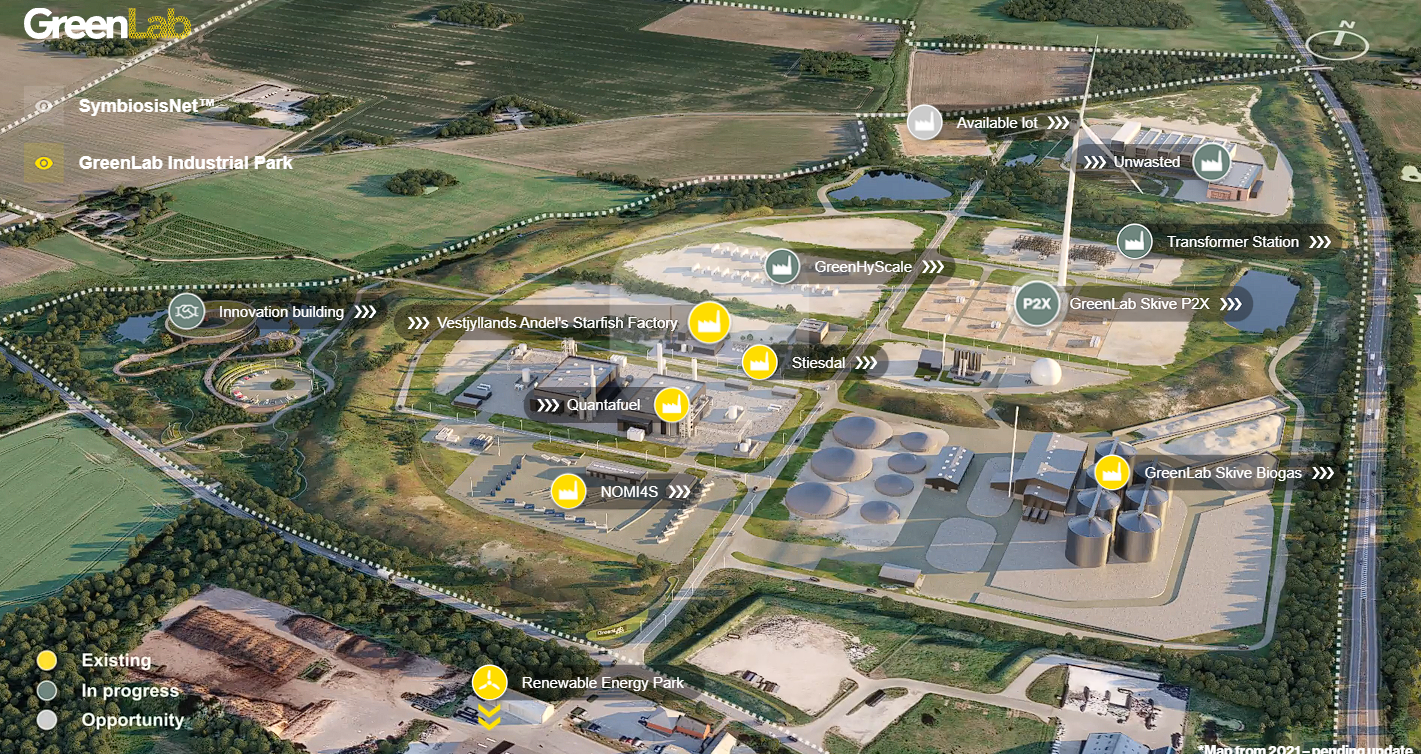

- 22 MW / 88 MWh, battery
- 10 MW, electric boiler
- 25 - 30 MW, biogas plant
- 6 MW electrolyser
- 1.5 MWh Electrical Load per hour
- Heat consumption biogas plant 5 MWh


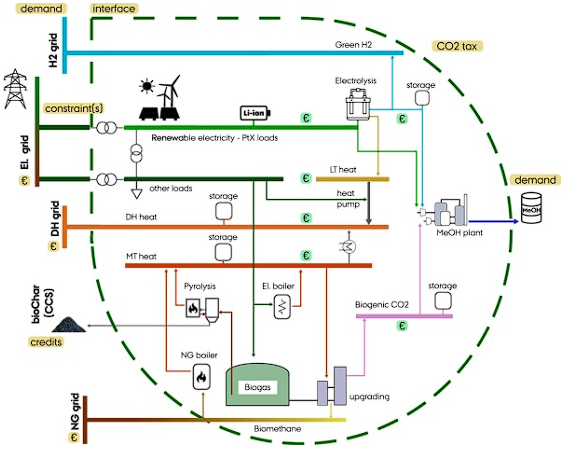

In [4]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

In [5]:
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

In [6]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

In [8]:
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [10]:
"Time Period in which our model is running";

hours_in_2020 = pd.date_range('2020-01-01 00:00Z',
                              '2020-12-31 23:00Z',
                              freq='h')

In [14]:
n = pypsa.Network()
n.set_snapshots(hours_in_2020)

n.add("Carrier", "gas", co2_emissions=0.19) # in t_CO2/MWh_th
n.add("Carrier", "onshorewind")
n.add("Carrier", "offshorewind")
n.add("Carrier", "nuclear")
n.add("Carrier","solar")
n.add("Carrier","heat")
n.add("Carrier","heat pump")

# CAPEX values for different technologies (in €/MW)
offshoreWind_capex = 2.8e6
onshoreWind_capex = 1.4e6
solar_capex = 628e3
ccgt_capex = 1.04e6
nuclear_capex = 11.08e6
electrolyzer_capex = 350e3
h2_tank_capex = 8.4e3
fuel_cell_capex = 339e3